# AMDF local: trước/sau và thí nghiệm độ dài khung

AMDF (average magnitude difference function) đo mức khác nhau giữa tín hiệu và bản dịch theo độ trễ. Đáy thấp gợi ý chu kỳ lặp; F0 = tần số lấy mẫu / độ trễ. F0 là tần số cơ bản, đơn vị Hz.

Notebook này tính lại AMDF thực trên bốn WAV train local. Có hai nhánh: không cổng năng lượng và có cổng năng lượng. So sánh baseline với bản đã sửa từ ngày05/10, rồi chạy vòng mới H23 cho frame20/25/40ms. Không đọc test, không mount Drive. Các cải thiện cũ và thí nghiệm mới được ghi riêng.

Nhãn V/UV/SIL là hữu thanh/vô thanh/khoảng lặng. LAB còn có mean/std/count F0 cả file; chúng không phải cao độ chuẩn theo từng thời điểm.


In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd

REPO = Path('C:\\Users\\LAPTOP T&T\\VIOLETTA\\Documents\\ChatGPT\\XLTN\\XLTN-BT2')
WORKBENCH = REPO / 'research_workbench_2026_10_07'
assert (REPO / 'TinHieuHuanLuyen').is_dir()
sys.path.insert(0, str(WORKBENCH))
import amdf_frames as experiment
core, audit = experiment.core, experiment.audit
plt = audit.plt
print('WAV train:', core.TRAIN)
print('LAB thống kê:', core.TRAIN_GT)
print('Notebook chỉ sử dụng train local.')


WAV train: C:\Users\LAPTOP T&T\VIOLETTA\Documents\ChatGPT\XLTN\XLTN-BT2\TinHieuHuanLuyen
LAB thống kê: C:\Users\LAPTOP T&T\VIOLETTA\Documents\ChatGPT\XLTN\XLTN-BT2\research_3gt_2026_10_05\train_3gt
Notebook chỉ sử dụng train local.


## 1. Đọc dữ liệu và đối chiếu cấu hình

Ngưỡng pitch quyết định dip AMDF có đủ thấp để coi khung là hữu thanh. Cổng năng lượng còn yêu cầu relative RMS lớn hơn ngưỡng: RMS của khung chia phân vị95% RMS trong chính file.

Baseline chọn đáy mạnh nhất riêng từng khung. Bản cải tiến giữ nhiều đáy làm ứng viên và chọn một đường F0 với phạt bước nhảy, để giảm việc nhảy giữa chu kỳ và bội chu kỳ. Nhánh không energy còn đổi phương pháp học ngưỡng; không quy mọi cải thiện của nhánh đó cho riêng chọn đường.


In [2]:
items = core.load_training()
frozen = json.loads((core.RESULTS / 'frozen_config.json').read_text(encoding='utf-8'))
history = json.loads((core.RESULTS / 'selection_summary.json').read_text(encoding='utf-8'))
models = {}
for family in ('AMDF_no_energy', 'AMDF_energy'):
    models[family + '_baseline'] = history[family]['baseline']['config']
    models[family + '_improved'] = frozen['models'][family]['config']
display(pd.DataFrame([{'model': name, **config} for name, config in models.items()]).fillna('không áp dụng'))
display(pd.DataFrame([{'file': item['file'], 'fs': item['fs'], 'frames': len(item['times']), **item['stats']} for item in items]))


model,algorithm,frame_ms,candidate,jump_cost,octave_cost,median,energy,threshold_method,preprocess
AMDF_no_energy_baseline,AMDF,25,không áp dụng,không áp dụng,không áp dụng,không áp dụng,không áp dụng,không áp dụng,không áp dụng
AMDF_no_energy_improved,AMDF,25,path,0.35,0.0,1.0,False,hist_classes,raw
AMDF_energy_baseline,AMDF,25,không áp dụng,không áp dụng,không áp dụng,không áp dụng,True,không áp dụng,không áp dụng
AMDF_energy_improved,AMDF,25,path,0.35,0.0,1.0,True,không áp dụng,raw


file,fs,frames,F0mean,F0std,F0num
phone_F1.wav,16000,322,215.6,20.6,148.0
phone_M1.wav,16000,414,123.7,16.8,232.0
studio_F1.wav,44100,284,229.6,36.8,127.0
studio_M1.wav,44100,271,116.9,26.4,82.0


## 2. Tính lại kết quả trước/sau

Train dùng cả bốn file để học ngưỡng rồi chấm chính các file đó. LOFO (leave one file out) giữ một file để chấm, học ngưỡng bằng ba file còn lại và lặp đủ bốn lần. LOFO ở đây giữ cố định các cấu hình đã chọn trước đó; vẫn có ảnh hưởng của việc nghiên cứu nhiều lần trên cùng dữ liệu.

Average MAPE là trung bình ba lỗi phần trăm mean/std/count trong mỗi file, rồi trung bình bốn file. Macro F1 và recall chỉ chấm V/UV; số SIL dự đoán hữu thanh được báo riêng. Không gộp SIL vào FP V/UV.


In [3]:
all_rows, summaries = [], []
saved_train = pd.read_csv(core.RESULTS / 'final_train_test_per_file.csv')
for name, config in models.items():
    family, version = name.rsplit('_', 1)
    for split in ('train', 'lofo'):
        rows = core.evaluate(items, config) if split == 'train' else core.lofo(items, config)
        summary = core.summarize(rows)
        reference = history[family]['baseline']['full_train' if split == 'train' else 'lofo'] if version == 'baseline' else history[family][split]
        for metric in ('average_mape', 'F0std_mape', 'macro_f1', 'recall_v', 'false_voiced_sil'):
            assert np.isclose(summary[metric], reference[metric], atol=1e-8), (name, split, metric)
        if split == 'train':
            reference_rows = saved_train[(saved_train.model == family) & (saved_train.version == version) & (saved_train.split == 'train')].sort_values('file')
            columns = ['F0mean', 'F0std', 'F0num', 'average_mape', 'macro_f1', 'false_voiced_sil']
            assert np.allclose(rows.sort_values('file')[columns], reference_rows[columns], atol=1e-8)
        summaries.append({'model': name, 'split': split, **summary})
        all_rows.extend({'model': name, 'split': split, **row} for row in rows.to_dict('records'))
summary_table = pd.DataFrame(summaries)
detail_table = pd.DataFrame(all_rows)
display(summary_table[['model', 'split', 'average_mape', 'F0std_mape', 'macro_f1', 'recall_v', 'recall_uv', 'balanced_accuracy', 'false_voiced_sil', 'F0num']].round(6))
display(detail_table[['model', 'split', 'file', 'average_mape', 'F0std_mape', 'macro_f1', 'false_voiced_sil']].round(6))
summary_table.to_csv(WORKBENCH / 'results/AMDF_notebook_summary.csv', index=False)
detail_table.to_csv(WORKBENCH / 'results/AMDF_notebook_per_file.csv', index=False)
print('PASS: tất cả số liệu AMDF trước/sau khớp kết quả đã lưu trong1e-8.')


PASS: tất cả số liệu AMDF trước/sau khớp kết quả đã lưu trong1e-8.


model,split,average_mape,F0std_mape,macro_f1,recall_v,recall_uv,balanced_accuracy,false_voiced_sil,F0num
AMDF_no_energy_baseline,train,26.784050,65.074895,0.872079,0.894080,0.934520,0.914300,50,606
AMDF_no_energy_baseline,lofo,27.030428,65.011762,0.869478,0.891006,0.934520,0.912763,51,604
AMDF_no_energy_improved,train,16.514426,36.716226,0.858014,0.878336,0.934520,0.906428,46,593
AMDF_no_energy_improved,lofo,16.659552,37.310247,0.858014,0.878336,0.934520,0.906428,44,591
AMDF_energy_baseline,train,12.270267,28.962627,0.869716,0.881409,0.964937,0.923173,0,548
AMDF_energy_baseline,lofo,13.695884,33.128135,0.864626,0.876303,0.964937,0.920620,1,545
AMDF_energy_improved,train,4.876259,7.489567,0.869716,0.881409,0.964937,0.923173,0,548
AMDF_energy_improved,lofo,6.767627,12.855443,0.864626,0.876303,0.964937,0.920620,1,545


model,split,file,average_mape,F0std_mape,macro_f1,false_voiced_sil
AMDF_no_energy_baseline,train,phone_F1.wav,32.421811,91.806294,0.914139,2
AMDF_no_energy_baseline,train,phone_M1.wav,20.404969,52.944690,0.810729,1
AMDF_no_energy_baseline,train,studio_F1.wav,20.978192,51.965434,0.919439,22
AMDF_no_energy_baseline,train,studio_M1.wav,33.331227,63.583160,0.844007,25
AMDF_no_energy_baseline,lofo,phone_F1.wav,29.896656,84.004804,0.914139,1
AMDF_no_energy_baseline,lofo,phone_M1.wav,21.157570,53.763262,0.800325,1
AMDF_no_energy_baseline,lofo,studio_F1.wav,23.736261,58.695822,0.919439,24
AMDF_no_energy_baseline,lofo,studio_M1.wav,33.331227,63.583160,0.844007,25
AMDF_no_energy_improved,train,phone_F1.wav,13.652039,36.696420,0.909388,1
AMDF_no_energy_improved,train,phone_M1.wav,11.957349,24.975585,0.796903,1


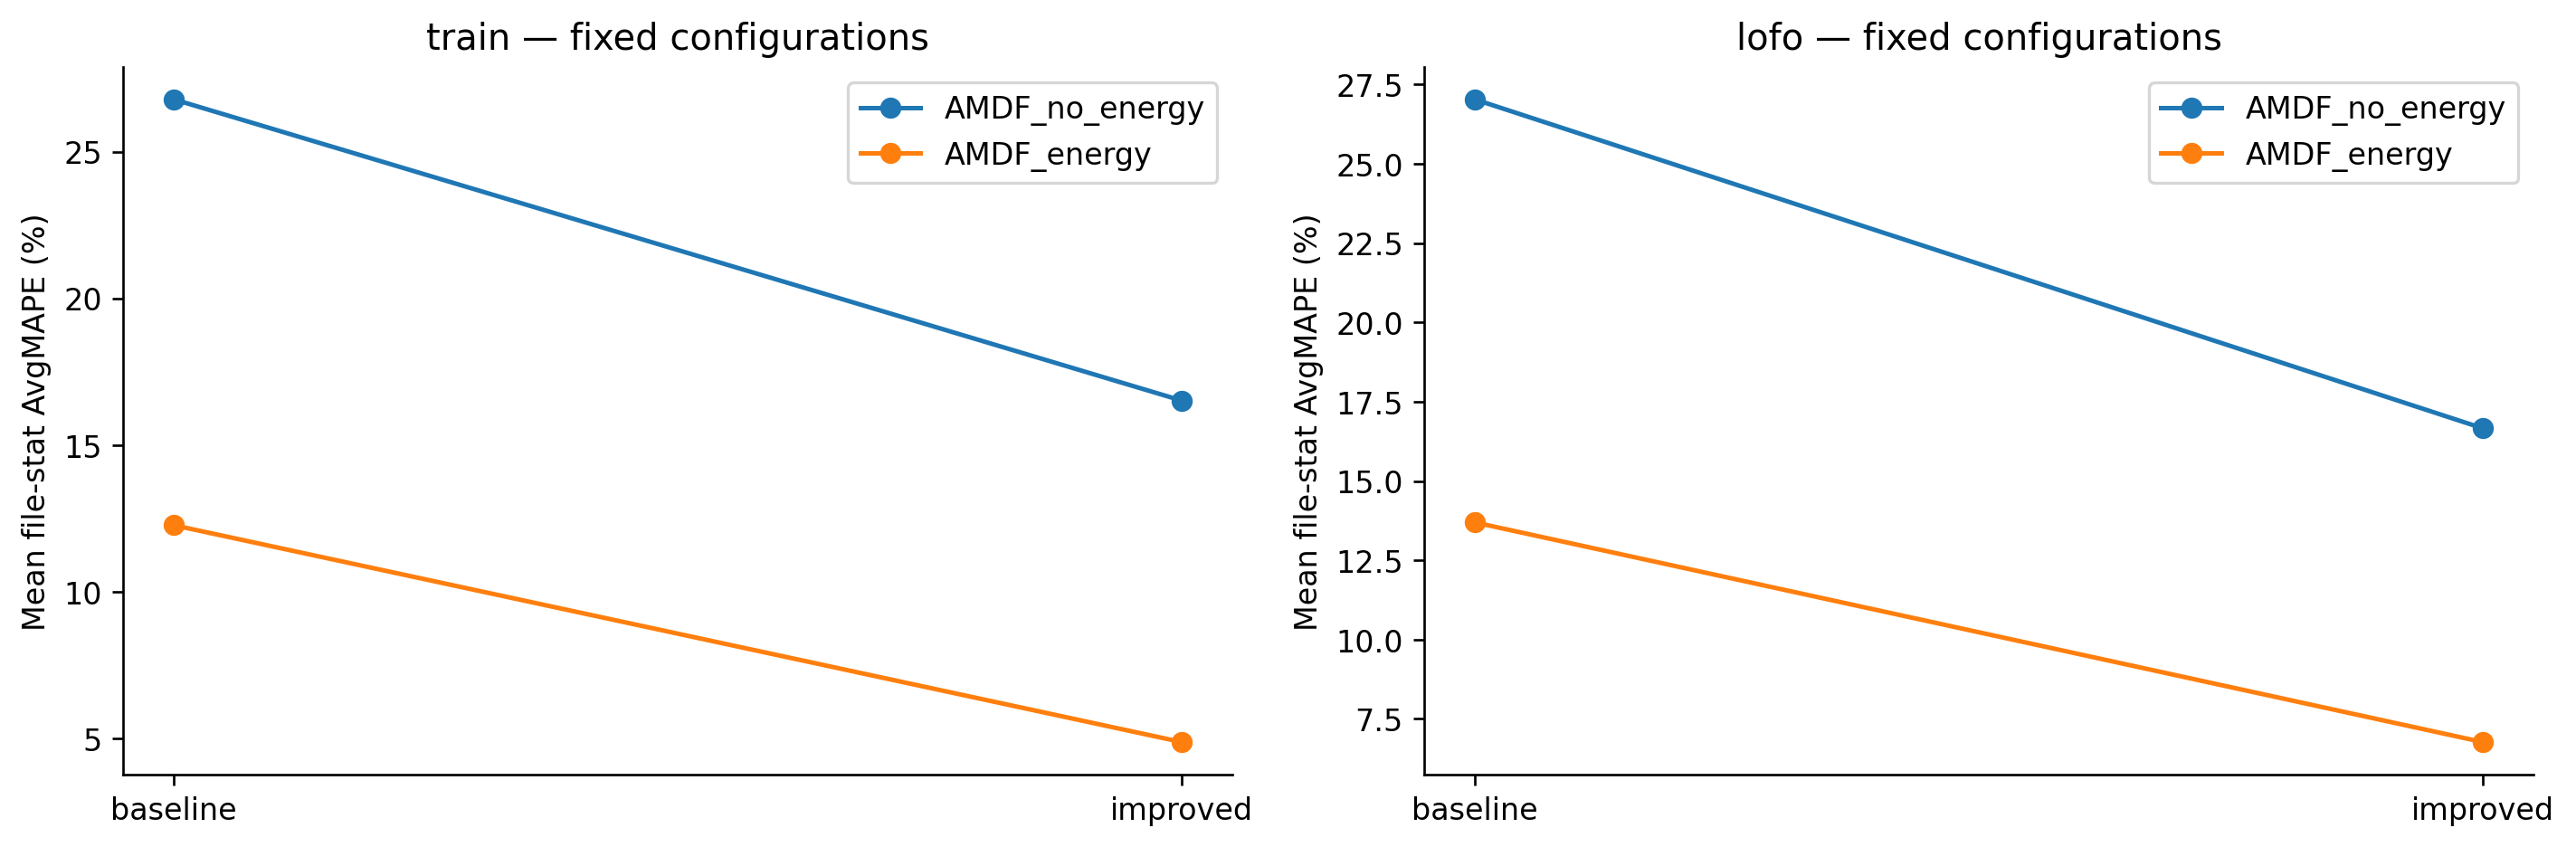

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, split in zip(axes, ('train', 'lofo')):
    table = summary_table[summary_table.split == split]
    for family in ('AMDF_no_energy', 'AMDF_energy'):
        before = table[table.model == family + '_baseline'].iloc[0]
        after = table[table.model == family + '_improved'].iloc[0]
        ax.plot(['baseline', 'improved'], [before.average_mape, after.average_mape], 'o-', label=family)
    ax.set(title=split + ' — fixed configurations', ylabel='Mean file-stat AvgMAPE (%)')
    ax.legend()
source = WORKBENCH / 'results/AMDF_notebook_summary.csv'
audit.save_figure('AMDF_before_after', fig, [source], 'AMDF trước/sau, tính lại trên train local; LOFO giữ cố định cấu hình.', 'Cấu hình đã chọn trên dữ liệu này trước đó; không phải nested mới hoặc pitch error từng khung.')
artifact = dict(audit.ARTIFACTS[-1])
artifact.update(generator='execute_amdf_notebook.py', generator_sha256=audit.digest(WORKBENCH / 'execute_amdf_notebook.py'), command='python research_workbench_2026_10_07/execute_amdf_notebook.py')
audit.json_write(WORKBENCH / 'results/AMDF_notebook_figure_manifest.json', {'figures': [artifact], 'builder_sha256': audit.digest(WORKBENCH / 'build_amdf_notebook.py')})
audit.ARTIFACTS.clear()
from PIL import Image
display(Image.open(WORKBENCH / 'figures/AMDF_before_after.png'))


## 3. Xem một đường AMDF thực

Normalized AMDF chia tổng sai khác tuyệt đối cho tổng biên độ tuyệt đối của hai đoạn chồng lấn. Trong mã này mỗi lag dùng số mẫu chồng lấn tương ứng; không mặc định công thức giống mọi bài AMDF khác.

Ví dụ chọn khung V nội bộ ở giữa danh sách khung của phone_F1, không chọn theo lỗi nhỏ nhất. Đáy đánh dấu là ứng viên riêng khung. Path có thể chọn một đáy khác khi xét cả chuỗi; chưa có reference F0 từng khung để xác minh đáy nào đúng.


File/tâm khung: phone_F1.wav 1.3225 s
NAMDF dip: 0.10184218288486241 lag: 88.26768956762186 candidate F0: 181.2667815185352 Hz


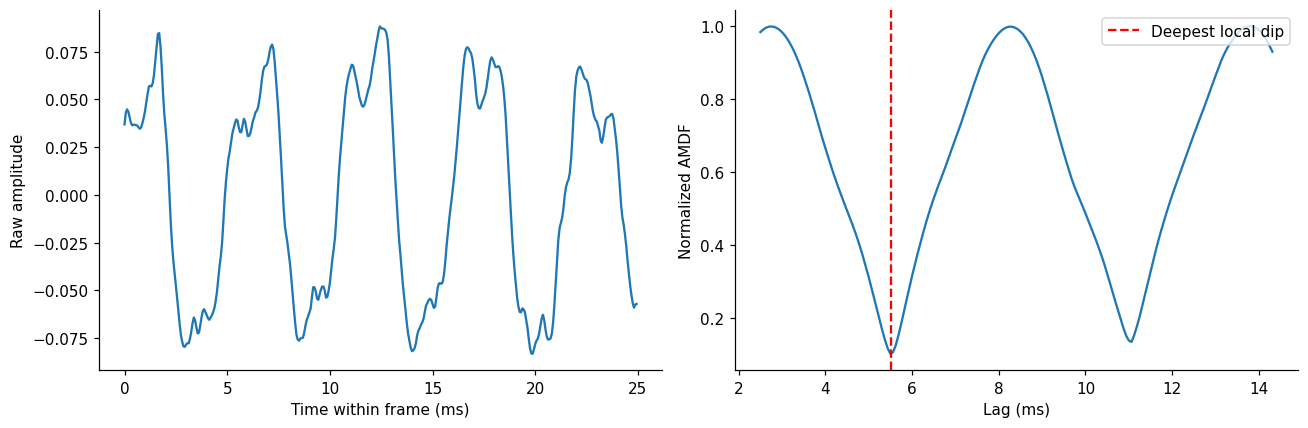

In [5]:
item = next(x for x in items if x['file'] == 'phone_F1.wav')
fs, audio = core.load_audio(core.TRAIN / item['file'])
indices = np.flatnonzero((item['labels'] == 'v') & ~item['boundary'])
index = int(indices[len(indices) // 2])
length, hop = round(fs * .025), round(fs * .010)
frame = audio[index * hop:index * hop + length]
score, lag_integer, lag_refined, lag_grid, curve = core.AMDF['deepest_local_dip'](frame, fs)
print('File/tâm khung:', item['file'], item['times'][index], 's')
print('NAMDF dip:', score, 'lag:', lag_refined, 'candidate F0:', fs / lag_refined, 'Hz')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(np.arange(length) * 1000 / fs, frame)
axes[0].set(xlabel='Time within frame (ms)', ylabel='Raw amplitude')
axes[1].plot(lag_grid * 1000 / fs, curve)
axes[1].axvline(lag_refined * 1000 / fs, ls='--', color='red', label='Deepest local dip')
axes[1].set(xlabel='Lag (ms)', ylabel='Normalized AMDF')
axes[1].legend()
fig.tight_layout()
display(fig)
plt.close(fig)


## 4. H23: chọn độ dài khung riêng cho AMDF

Vòng mới chỉ mở frame20/25/40ms, giữ hop10ms và mọi thành phần khác của AMDF có energy đã sửa. Registry và tiêu chí đã commit trước chạy. File vòng ngoài bị loại khỏi cả chọn cấu hình và học ngưỡng; inner LOFO chỉ dùng ba file khác.

Chấm trên lưới thời điểm25/10 chung để count không đổi thước đo. Bảng ghi native count và coverage riêng. Những điểm ngoài hỗ trợ là bỏ dự đoán; không nội suy xuyên UV hay sửa count cho khớp GT.

Cell sau chỉ chạy H23 nếu chưa có kết quả; khi chạy lại notebook, nó xác minh kết quả và source hash hiện có thay vì ghi đè thí nghiệm đã lưu.


H23: features ready phone_F1.wav
H23: features ready phone_M1.wav
H23: features ready studio_F1.wav
H23: features ready studio_M1.wav
H23: selected final: amdf_f25_h10
H23: selected phone_F1.wav: amdf_f25_h10
H23: selected phone_M1.wav: amdf_f25_h10
H23: selected studio_F1.wav: amdf_f25_h10
H23: selected studio_M1.wav: amdf_f25_h10
{
  "checks": {
    "train_mape_relative_10_percent": false,
    "lofo_mape_relative_5_percent": false,
    "lofo_f1_drop_at_most_01": true,
    "lofo_recall_v_drop_at_most_01": true,
    "lofo_sil_increase_at_most_1": true,
    "lofo_no_file_mape_worse_by_over_2pp": true,
    "lofo_phone_f1_std_not_worse": true,
    "selected_lofo_mape_relative_5_percent": false
  },
  "eligible": false,
  "nested_status": "Outer file excluded from every inner fit and selection; selected LOFO is separate.",
  "champion_promoted": false
}
    model  split  average_mape  macro_f1  recall_v  false_voiced_sil
 accepted  train      4.876259  0.869716  0.881409                 0


model,split,average_mape,macro_f1,recall_v,false_voiced_sil
accepted,train,4.876259,0.869716,0.881409,0
accepted,lofo,6.767627,0.864626,0.876303,1
accepted,nested,6.767627,0.864626,0.876303,1
candidate,train,4.876259,0.869716,0.881409,0
candidate,lofo,6.767627,0.864626,0.876303,1
candidate,nested,6.767627,0.864626,0.876303,1


outer_held,id,frame_ms,hop_ms,C
final,amdf_f25_h10,25,10,None
phone_F1.wav,amdf_f25_h10,25,10,None
phone_M1.wav,amdf_f25_h10,25,10,None
studio_F1.wav,amdf_f25_h10,25,10,None
studio_M1.wav,amdf_f25_h10,25,10,None


option_id,file,average_mape,F0std_mape,macro_f1,recall_v,projection_coverage,native_frames,native_f0_count
amdf_f20_h10,phone_F1.wav,21.628853,57.174221,0.880699,0.869281,1.000000,323,138
amdf_f20_h10,phone_M1.wav,8.005089,8.041920,0.776823,0.790984,1.000000,415,197
amdf_f20_h10,studio_F1.wav,5.997359,3.136568,0.856924,0.886179,1.000000,285,109
amdf_f20_h10,studio_M1.wav,9.577074,10.815391,0.756646,0.734043,1.000000,272,69
amdf_f25_h10,phone_F1.wav,13.303347,36.290329,0.914139,0.908497,1.000000,322,143
amdf_f25_h10,phone_M1.wav,5.003046,4.706237,0.800325,0.831967,1.000000,414,209
amdf_f25_h10,studio_F1.wav,4.346475,3.226869,0.911765,0.934959,1.000000,284,115
amdf_f25_h10,studio_M1.wav,4.417638,7.198337,0.832276,0.829787,1.000000,271,78
amdf_f40_h10,phone_F1.wav,1.566882,1.112054,0.908784,0.908497,0.996894,321,143
amdf_f40_h10,phone_M1.wav,10.686380,14.069291,0.771925,0.778689,0.997585,413,193


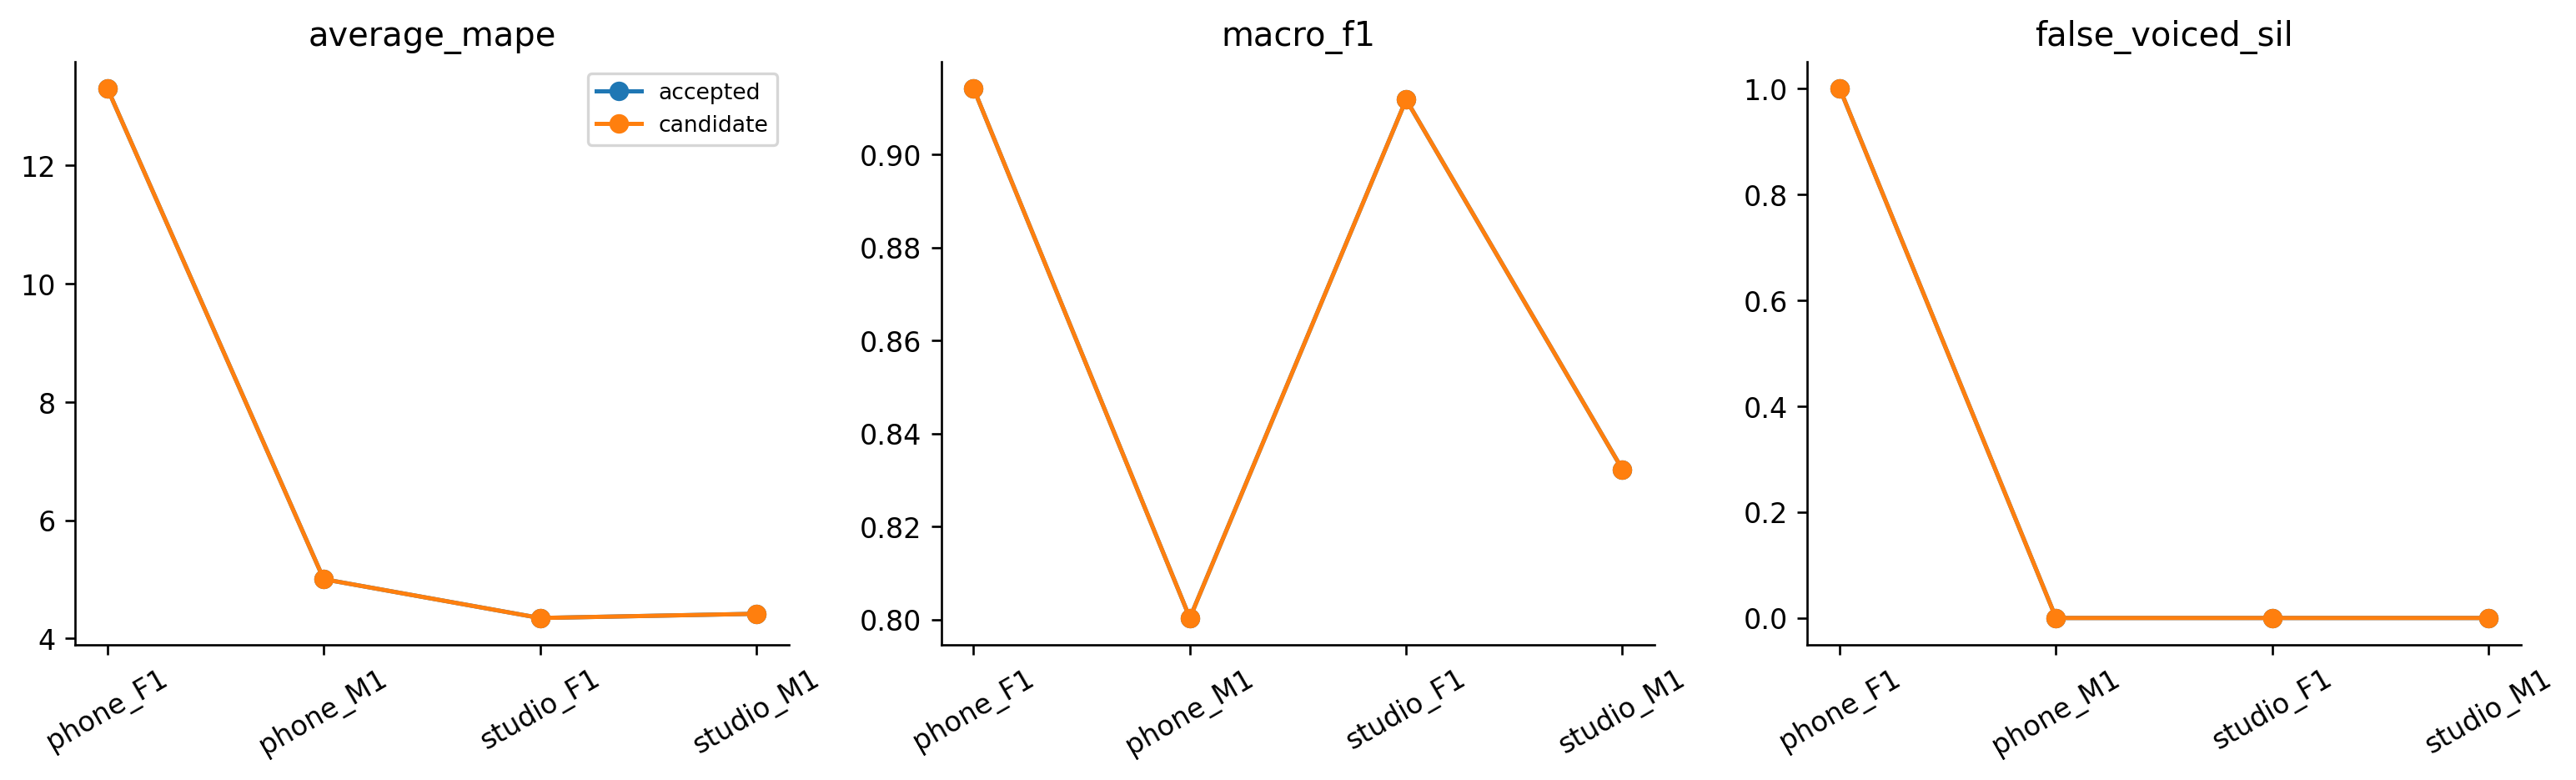

In [6]:
result_path = WORKBENCH / 'results/H23_experiment.json'
if not result_path.exists():
    experiment.run('H23')
else:
    print('H23 đã có kết quả; đọc và xác minh source, không ghi đè.')
import verify_results
verify_results.verify('H23')
result = json.loads(result_path.read_text(encoding='utf-8'))
display(pd.DataFrame([{'model': model, 'split': split, **values} for model, splits in result['summaries'].items() for split, values in splits.items()])[['model', 'split', 'average_mape', 'macro_f1', 'recall_v', 'false_voiced_sil']].round(6))
display(pd.DataFrame([{'outer_held': choice['outer_held'], **choice['option']} for choice in result['selections']]))
display(pd.read_csv(WORKBENCH / 'results/H23_fixed_frame_lofo.csv')[['option_id', 'file', 'average_mape', 'F0std_mape', 'macro_f1', 'recall_v', 'projection_coverage', 'native_frames', 'native_f0_count']].round(6))
print('Gate:', result['decision'])
display(Image.open(WORKBENCH / 'figures/H23_nested.png'))


## 5. Đọc kết luận đúng phạm vi

Có cải thiện AMDF so baseline cũ không đồng nghĩa mọi cấu hình thử thêm sẽ cải thiện tiếp. Train, fixed LOFO và nested selection trả lời các câu hỏi khác nhau; không thay điểm nested xấu bằng điểm selected LOFO đẹp.

Bốn file đã xem nhiều lần không đủ tách ảnh hưởng giới tính, người nói, thiết bị và nội dung nói. Nếu H23 không đạt, giữ cải tiến AMDF đã có, lưu kết quả thất bại và phân tích trước chọn cơ chế tiếp theo. Không tuyên bố mọi F0 đúng chỉ vì mean/std/count gần LAB.

Tất cả code cells được chạy nguyên source bởi execute_amdf_notebook.py; chỉ bộ hiển thị bảng/hình được thay cho chế độ headless. Đây không phải lần chạy bằng Jupyter kernel. Source không được thay đường dẫn trong bộ nhớ; notebook chạy lại trên môi trường local có các thư viện đã dùng.
